In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

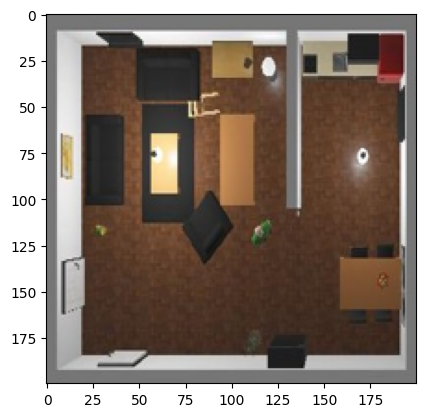

In [11]:
import matplotlib.image as mpimg
from PIL import Image

# Load the image
# Replace 'your_image.png' with the actual path to your image file
img = Image.open('../media/.apartment_cropped.png') 

# img_temp = img[85:-90,85:-300]

img_temp = img.resize((200,200))
# Display the image
plt.imshow(img_temp)

# Show the plot window
plt.show()

In [2]:
trajectory = pd.read_csv("../trajectory/p3/p3_apartment_s2.csv")
# pd.read_csv('pedestrian_positions_20251124_064305.csv')

trajectory = trajectory[['x', 'y']]

trajectory.head()

# Drop first 35 rows and then take every 10th row
trajectory_drop = trajectory.iloc[35::10]
trajectory_drop.head()

,x,y
35,-1.5,-3.0
45,-1.5,-3.0
55,-1.5,-3.0
65,-1.5,-3.0
75,-1.5,-3.0


In [3]:
trajectory_drop.describe()

,x,y
count,1039.000000,1039.000000
mean,-4.582863,-3.188529
std,2.746331,1.402171
min,-8.621000,-5.864000
25%,-7.727000,-4.048000
50%,-4.286000,-3.000000
75%,-1.500000,-2.398000
max,-1.500000,-0.478000


<Axes: xlabel='x', ylabel='y'>

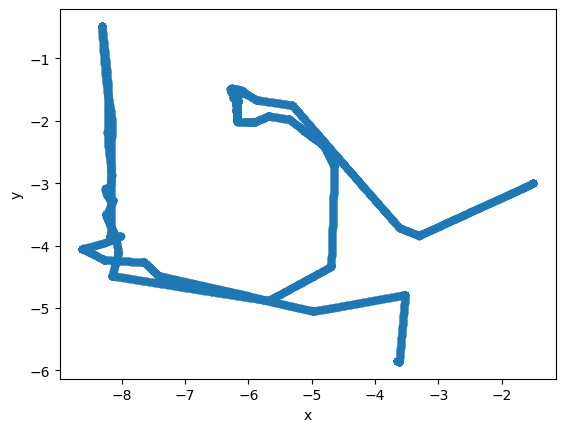

In [4]:
trajectory.plot.scatter(x='x', y='y')

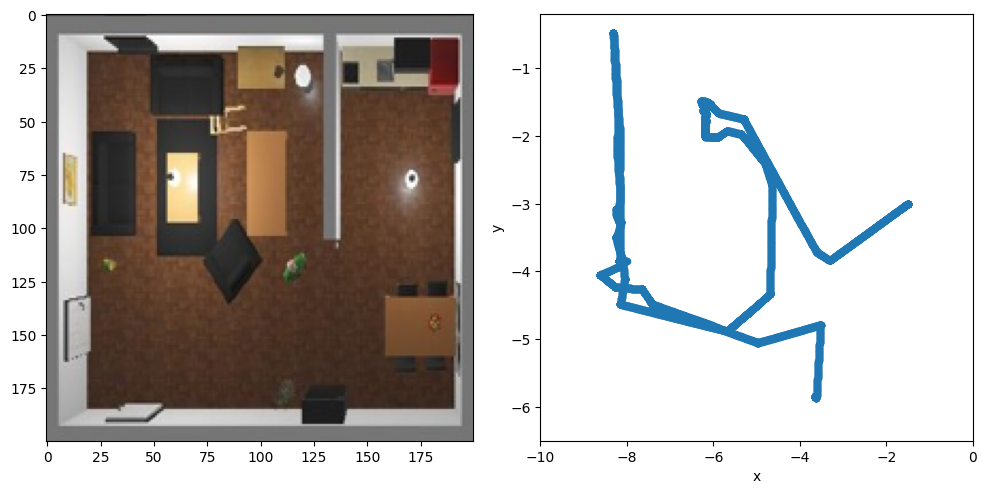

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(img_temp)

trajectory.plot.scatter(x='x', y='y', ax=ax2)
ax2.set_xlim(-10, 0)
ax2.set_ylim(-6.5, -0.2)
# plt.legend()
# ax2.title("Recorded Trajectory")
plt.tight_layout()
plt.savefig('../media/trajectory_plot.png')
plt.show()


  Cluster 0: center at [-1.50059557 -3.00027424]
  Cluster 1: center at [-5.09874194 -2.15509677]
  Cluster 2: center at [-6.15683516 -1.69615385]
  Cluster 3: center at [-8.15294444 -3.83172222]
  Cluster 4: center at [-8.18309091 -3.36336364]
  Cluster 5: center at [-8.204  -3.1135]
  Cluster 6: center at [-8.3134557  -0.48389873]
  Cluster 7: center at [-8.61223288 -4.04946575]
  Cluster 8: center at [-3.55418182 -4.81563636]
  Cluster 9: center at [-3.6460101  -5.84509091]


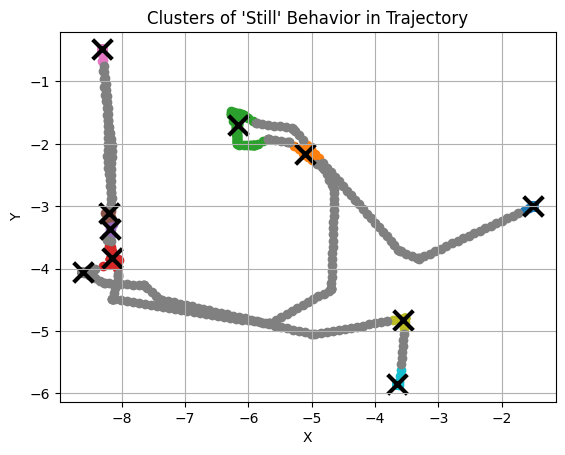

In [16]:
df = trajectory_drop[['x', 'y']].to_numpy()
db = DBSCAN(eps=0.15, min_samples=10).fit(df)

# df = trajectory[['x', 'y']].to_numpy()
# db = DBSCAN(eps=0.15, min_samples=100).fit(df)

labels = db.labels_

# -1 means noise (not in any cluster)
unique_clusters = set(labels) - {-1}
# print("Detected clusters:", unique_clusters)

# Compute cluster centers (where person stays the most)
cluster_centers = {}

for cluster_id in unique_clusters:
    points = df[labels == cluster_id]
    center = points.mean(axis=0)
    cluster_centers[cluster_id] = center

# print("\nCluster centers (likely 'still' locations):")
for cid, ctr in cluster_centers.items():
    print(f"  Cluster {cid}: center at {ctr}")

# ------------------------------------------
# Visualization
# ------------------------------------------
# plt.figure(figsize=(6, 6))

# Plot each cluster
for cluster_id in unique_clusters:
    pts = df[labels == cluster_id]
    plt.scatter(pts[:,0], pts[:,1], label=f"Cluster {cluster_id}")

# Plot noise
noise = df[labels == -1]
if len(noise) > 0:
    plt.scatter(noise[:,0], noise[:,1], color='gray', label='Noise')

# Plot centers
for cid, ctr in cluster_centers.items():
    plt.scatter(ctr[0], ctr[1], marker='x', s=200, linewidths=3, color='black')

# plt.legend()
plt.title("Clusters of 'Still' Behavior in Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

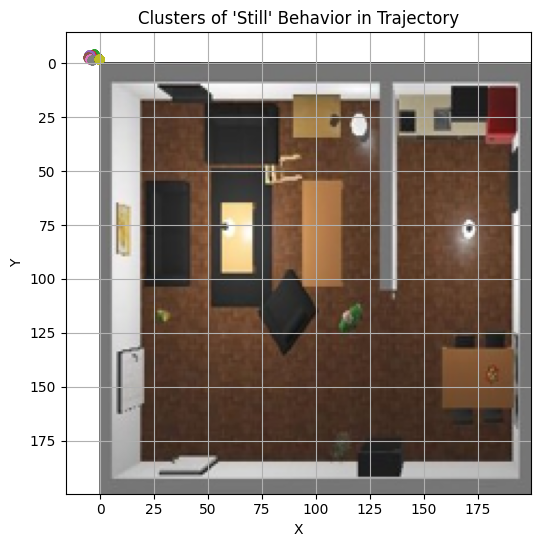

In [8]:
plt.figure(figsize=(6, 6))

# img_temp = img[85:-90,85:-300]

plt.imshow(img_temp)

scale = 1

# Plot each cluster
for cluster_id in unique_clusters:
    pts = df[labels == cluster_id]
    plt.scatter((pts[:,0])*scale + 000, (pts[:,1])*scale + 000, label=f"Cluster {cluster_id}")

# Plot noise
# noise = df[labels == -1]
# if len(noise) > 0:
#     plt.scatter(noise[:,0], noise[:,1], color='gray', label='Noise')

# Plot centers
# for cid, ctr in cluster_centers.items():
#     plt.scatter(ctr[0], ctr[1], marker='x', s=200, linewidths=3, color='black')



# plt.legend()
plt.title("Clusters of 'Still' Behavior in Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

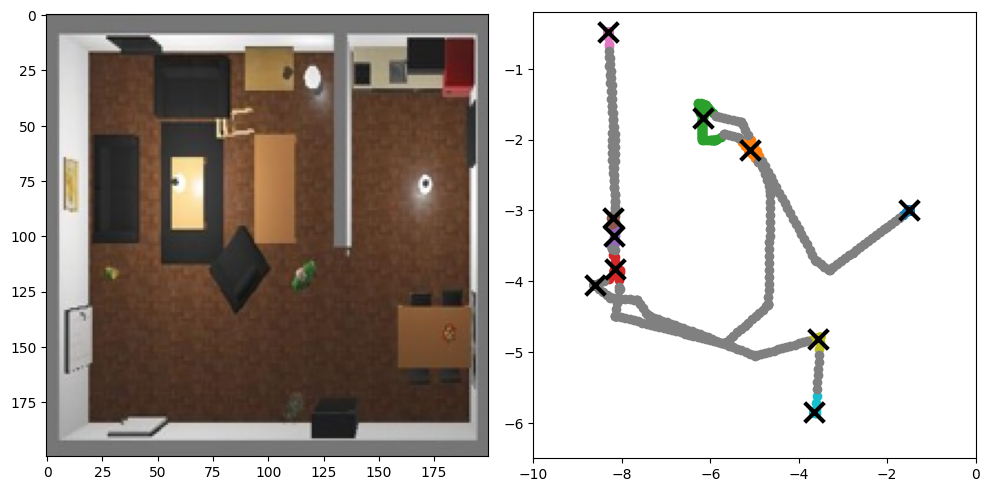

<Figure size 640x480 with 0 Axes>

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(img_temp)

# axes[1].set_xlim([-10, 0])  # Adjust as needed for your specific range
# axes[1].set_ylim([-10, 0])

for cluster_id in unique_clusters:
    pts = df[labels == cluster_id]
    ax2.scatter(pts[:,0], pts[:,1], label=f"Cluster {cluster_id}")

# Plot noise
noise = df[labels == -1]
if len(noise) > 0:
    ax2.scatter(noise[:,0], noise[:,1], color='gray', label='Noise')

# Plot centers
for cid, ctr in cluster_centers.items():
    ax2.scatter(ctr[0], ctr[1], marker='x', s=200, linewidths=3, color='black')

ax2.set_xlim(-10, 0)
ax2.set_ylim(-6.5, -0.2)

plt.tight_layout()

# axes[0].set_xlabel('X-axis')

plt.show()
plt.savefig('../media/trajectory_cluster_plot.png')


In [15]:
import shutil

destination_file = '../trajectory/center.csv'

with open(destination_file, 'w') as file:
    # Write the new line to the file, including a newline character for formatting
    file.write("x,y\n")
    for cid, ctr in cluster_centers.items():
        x, y = ctr
        sphere_text = f"{x},{y}\n"
        file.write(sphere_text)
        # break